# __Demo - proximity analysis__ [Work in progress]
### Basic usage example of processing and representing proximity data

This notebook displays a __demo process to be used be used to calculate proximity__ to a given points of interest within a given area of interest, __and then represent the data__ using Observatory's design style.

The notebook consists of the following steps:
* __Import libraries__
* __Analysis configuration__
* __Homogenize the input data's CRS for the analysis__
* __Download OSM roads and intersections__
* __Calculate proximity from each node to the points of interest__
* sdasad

## __Import libraries__

In order to use the functions required to process and represent data, we've developed a code library called `odc`, which stores functions that use other python libraries for the analysis and representation of data.

In [1]:
from pathlib import Path
current_path = Path().resolve()
for parent in current_path.parents:
    if parent.name == "odc":
        project_root = parent
        break
print(project_root)

import os
import sys

module_path = os.path.abspath(os.path.join(project_root))
if module_path not in sys.path:
    sys.path.append(module_path)
    print("Path found")
    import odc

/home/jovyan/odc
Path found


In [2]:
import geopandas as gpd
#import odc
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

## __Analysis configuration__

This cell specifies the location of input data and other parameters used within the proximity analysis.

In [3]:
# --------------- Location of input data
# Area of interest - Directory with location of input layer containing a polygon geometry that defines the area of interest were the analysis is to be performed.
aoi_dir = "../data/demo_files/demo_proximity/aoibuffer_saltillo_32614.gpkg"
# Points of interest - Directory with location of input layer containing a polygon geometry that defines the area of interest were the analysis is to be performed.
pois_dir = "../data/demo_files/demo_proximity/pois_saltillo_32614.gpkg"

# --------------- Analysis parameters
# Projection CRS (str) - CRS used when projecting features to perform geoprocessing (e.g. "6372" could be used anywere in Mexico)
projection_crs = 'EPSG:32614'
# Walking speed (float) - Speed of travel in km/hr for the proximity calculation. (e.g. a pedestrian speed could be set at around 4km/hr)
walking_speed = 4
# Points of interest name (str) - Name to be used within the analysis and returned in the output. (e.g. pois_dir containing schools)
pois_name = 'schools'
# Count amount of pois at a cetain distance (tupple) - Tupple which, if first value is True, uses the second value to count the number of pois within a certain walking time from each node. (e.g. count the number of schools at a 10 minute walk)
count_pois = (True,10)
# Output hexgrid resolution (list of int between 8 and 11) - Specifies resolution of H3 hexagonal cells. For more information consult resolutions in https://h3geo.org/
hexs_res = [8, 9, 10]

# --------------- Output saving
# Output directory for nodes and hexagons (str) - Directory with the location where the output nodes and hexs with proximity analysis will be saved
output_dir = f"../data/to/output/"

## __Homogenize the input data's CRS for the analysis__

Both the area of interest and the points of interest are __set to the projection_crs.__

<Axes: >

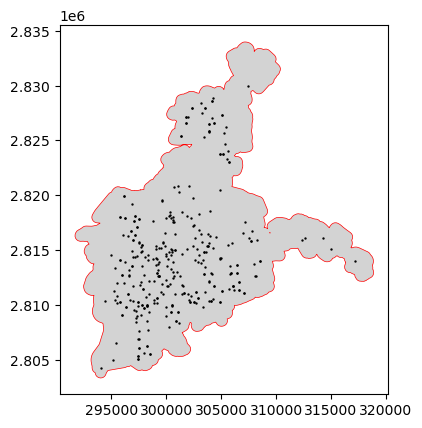

In [4]:
# --------------- Prepare the area of interest CRS
aoi_gdf = gpd.read_file(aoi_dir)
if aoi_gdf.crs is None:
    aoi_gdf = aoi_gdf.set_crs(projection_crs)
elif aoi_gdf.crs != projection_crs:
    aoi_gdf = aoi_gdf.to_crs(projection_crs)
    
# --------------- Prepare the points of interest CRS
pois_gdf = gpd.read_file(pois_dir)
if pois_gdf.crs is None:
    pois_gdf = pois_gdf.set_crs(projection_crs)
elif pois_gdf.crs != projection_crs:
    pois_gdf = pois_gdf.to_crs(projection_crs)

# Show input data (This part creates the following map for visualization purposes)
fig,ax = plt.subplots()
pois_gdf.plot(ax=ax,zorder=2,markersize=.5,color='black')
aoi_gdf.plot(ax=ax,zorder=1, facecolor='lightgray',edgecolor='red',lw=.5)

## __Download OSM roads and intersections__

The function __odc.download_osm_network()__ is used to __download from Open Street Map the navigable network G formed by nodes (intersections) and edges (streets)__ within the provided area of interest.

In [ ]:
G, nodes, edges = odc.download_osm_network(area_of_interest = aoi_gdf, # Area of interest 
                                           method='from_bbox', # 'from_polygon' crops the network to the available network, 'from_bbox' crops the network to a bounding box around the aoi
                                           network_type='all_private'
                                          )

print(f"Downloaded {len(nodes)} nodes and {len(edges)} edges.")

## __Calculate proximity from each node to the points of interest__

The function __odc.calculate_time_to_pois()__ recieves as input the downloaded area of interest network, the points of interest and the analysis configuration previously set, and __returns all nodes (intersections) with the specified proximity data.__

In [ ]:
nodes_with_time = odc.calculate_time_to_pois(G = G,
                                             nodes = nodes,
                                             edges = edges,
                                             pois = pois,
                                             poi_name = pois_name,
                                             walking_speed = walking_speed,
                                             count_pois = count_pois,
                                             projected_crs = projected_crs
                                            )

# Show
print(nodes_with_time.crs)
print(nodes_with_time.shape)
nodes_with_time.head(2)

## __Save the nodes proximity analysis to output directory__

In [ ]:
nodes_with_time.to_file(output_dir, driver="GPKG")
print(f"Results saved to {output_dir}")